In [1]:
import geopandas as gpd
import rasterio
from scipy import ndimage
import os

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
import time
from datetime import datetime

In [42]:
df= pd.read_csv("../data/datos_simma.csv")

In [44]:
#contar cuantos eventos hay en caldas
eventos_caldas = df[df['Departamento'] == 'CALDAS']
len(eventos_caldas)

343

<Axes: title={'center': 'Eventos por Municipio en Caldas'}, xlabel='Municipio'>

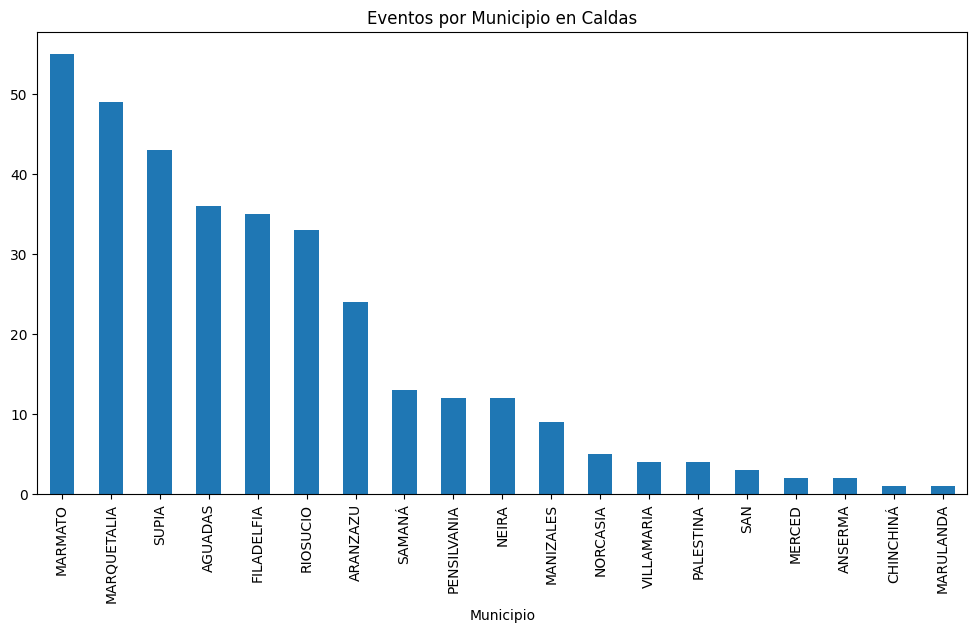

In [45]:
#Grafico de barras para ver eventos por Municipio
eventos_caldas['Municipio'].value_counts().plot(kind='bar', figsize=(12, 6), title='Eventos por Municipio en Caldas')

In [19]:
eventos_caldas.head()

,Tipo_Movimiento,Fecha,Departamento,Municipio,Altura_msnm,Latitud,Longitud,id
17,Deslizamiento,02/08/2022,CALDAS,FILADELFIA,1.755,5.235556,-75.564444,18
19,Deslizamiento,31/07/2022,CALDAS,FILADELFIA,1.030,5.248611,-75.609722,20
20,Deslizamiento,30/07/2022,CALDAS,FILADELFIA,1.597,5.272222,-75.547222,21
21,Deslizamiento,30/07/2022,CALDAS,FILADELFIA,1.622,5.276389,-75.551667,22
22,Deslizamiento,29/07/2022,CALDAS,AGUADAS,1.375,5.608056,-75.492222,23


In [22]:
# Convertir a datetime
eventos_caldas['Fecha'] = pd.to_datetime(eventos_caldas['Fecha'],format='%d/%m/%Y')

C:\Users\Alexander Sanguino\AppData\Local\Temp\ipykernel_19236\2635005002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eventos_caldas['Fecha'] = pd.to_datetime(eventos_caldas['Fecha'],format='%d/%m/%Y')


In [40]:
#ver la fecha minima y maxima
print("Fecha mínima:", eventos_caldas['Fecha'].min())
print("Fecha máxima:", eventos_caldas['Fecha'].max())

Fecha mínima: 2000-10-28 00:00:00
Fecha máxima: 2022-08-02 00:00:00


In [ ]:
#creamos geometría de los datos de eventos para análisis espacial
eventos_gdf = gpd.GeoDataFrame(
    eventos_caldas, 
    geometry=gpd.points_from_xy(eventos_caldas['Longitud'], eventos_caldas['Latitud']),
    crs='EPSG:4326'
)

# Guardar como shapefile
eventos_gdf.to_file('../data/processed/caldas/eventos_caldas.shp')
print(f"Eventos guardados como shapefile: {len(eventos_gdf)} puntos")

Eventos guardados como shapefile: 343 puntos


C:\Users\Alexander Sanguino\AppData\Local\Temp\ipykernel_19236\85016881.py:8: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  eventos_gdf.to_file('../data/processed/caldas/eventos_caldas.shp')
c:\Users\Alexander Sanguino\Desktop\SIATMA\.venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Tipo_Movimiento' to 'Tipo_Movim'
  ogr_write(
c:\Users\Alexander Sanguino\Desktop\SIATMA\.venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field Fecha create as date field, though DateTime requested.
  ogr_write(
c:\Users\Alexander Sanguino\Desktop\SIATMA\.venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Departamento' to 'Departamen'
  ogr_write(
c:\Users\Alexander Sanguino\Desktop\SIATMA\.venv\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Altura_msnm' to 'Altura_msn'
  ogr_write(


In [27]:
#Definir shapefile de caldas
departamentos = gpd.read_file('../data/DATOS/Departamento.shp')
print(departamentos.columns)  # Ver qué columnas tiene
print(departamentos['DeNombre'].unique())  # Ver nombres exactos

Index(['DeCodigo', 'DeNombre', 'DeArea', 'DeNorma', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')
['Area en Litigio Cauca - Huila' 'Caldas' 'Caquetá' 'Cundinamarca' 'Huila'
 'Meta' 'Quindío' 'Risaralda' 'Santander' 'Tolima' 'Casanare'
 'San Andrés Providencia y Santa Catalina' 'Guaviare' 'Antioquia'
 'Atlántico' 'Bolívar' 'Boyacá' 'Cauca' 'Cesar' 'Córdoba' 'Chocó'
 'La Guajira' 'Magdalena' 'Norte de Santander' 'Sucre' 'Valle del Cauca'
 'Arauca' 'Putumayo' 'Amazonas' 'Guainía' 'Vaupés' 'Vichada' 'Nariño']


In [28]:
caldas = departamentos[departamentos['DeNombre'] == 'Caldas'].copy()
print(f"Área de Caldas: {caldas.geometry.area.sum()/1000000:.0f} km²")

Área de Caldas: 7422 km²


In [ ]:
bounds = caldas.total_bounds  # [minx, miny, maxx, maxy]
print(f"Límites Caldas: {bounds}")


Límites Caldas: [4676039.5909 2088821.4615 4819841.3265 2196863.878 ]


In [ ]:
#Extrayendo el boundary de Caldas
caldas.to_file('../data/processed/caldas_boundary/caldas_boundary.shp')

In [ ]:
#quizá se incluyan luego:
suelos_caldas = gpd.read_file('../data/Datos/CALDAS_SUELOS_VF.shp')
print(suelos_caldas.columns)  # Ver qué columnas tiene
print(suelos_caldas['TIPO_RELIE'].value_counts())  # Ajustar nombre de columna

In [ ]:
# revisando el CRS de los archivos TIF
with rasterio.open('../data/processed/caldas/caldas_slope_9377.tif') as src:
    print(src.crs)


EPSG:9377


In [52]:
import pyproj

# Definimos transformación de 4326 a 9377
transformer = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:9377", always_xy=True)

# Aplicamos transformación
eventos_caldas[['x_9377', 'y_9377']] = eventos_caldas.apply(
    lambda row: pd.Series(transformer.transform(row['Longitud'], row['Latitud'])),
    axis=1
)


C:\Users\Alexander Sanguino\AppData\Local\Temp\ipykernel_19236\2064717928.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eventos_caldas[['x_9377', 'y_9377']] = eventos_caldas.apply(


In [ ]:
def extraer_variables_dem(df):
    """
    Extrae todas las variables DEM para cada evento
    """
    
    # Diccionario con todas tus variables DEM
    rutas_tif = {
        'slope': '../data/processed/caldas/caldas_slope_9377.tif',
        'aspect': '../data/processed/caldas/caldas_aspect_9377.tif', 
        'plan_curvature': '../data/processed/caldas/caldas_plan_curvature.tif',
        'profile_curvature': '../data/processed/caldas/caldas_profile_curvature.tif',
        'TRI': '../data/processed/caldas/caldas_ruggedness.tif',
        'TPI': '../data/processed/caldas/caldas_tpi_9377.tif',
        'flow_accumulation': '../data/processed/caldas/caldas_flow_accumulation.tif',
        'flow_direction': '../data/processed/caldas/caldas_flow_directions.tif',
        'TWI': '../data/processed/caldas/caldas_twi.tif'
    }
    
    # Coordenadas de todos los eventos
    coords = [(lon, lat) for lon, lat in zip(df['x_9377'], df['y_9377'])]
    
    # Extraer cada variable
    for variable, ruta in rutas_tif.items():
        print(f"Extrayendo {variable}...")
        
        with rasterio.open(ruta) as src:
            valores = [x[0] if x[0] is not None else np.nan for x in src.sample(coords)]
            df[variable] = valores
    
    return df

# Usar:
df_caldas = extraer_variables_dem(eventos_caldas)

In [62]:
df_caldas.head()

,Tipo_Movimiento,Fecha,Departamento,Municipio,Altura_msnm,Latitud,Longitud,id,slope,aspect,plan_curvature,profile_curvature,TRI,TPI,flow_accumulation,flow_direction,TWI,x_9377,y_9377
17,Deslizamiento,02/08/2022,CALDAS,FILADELFIA,1.755,5.235556,-75.564444,18,20.747070,102.045494,-0.008090,0.003533,27.935328,-1.263794,14400.0,2.0,25.517368,4.715844e+06,2.137101e+06
19,Deslizamiento,31/07/2022,CALDAS,FILADELFIA,1.030,5.248611,-75.609722,20,14.127755,293.507080,-0.000148,-0.010141,19.253408,1.732849,900.0,6.0,2.136631,4.710829e+06,2.138566e+06
20,Deslizamiento,30/07/2022,CALDAS,FILADELFIA,1.597,5.272222,-75.547222,21,27.591576,10.818542,-0.000169,-0.001090,38.323063,-0.680054,6300.0,0.0,24.690691,4.717770e+06,2.141149e+06
21,Deslizamiento,30/07/2022,CALDAS,FILADELFIA,1.622,5.276389,-75.551667,22,29.992960,50.941860,-0.135211,-0.000258,44.078968,3.752930,2700.0,1.0,23.843391,4.717279e+06,2.141611e+06
22,Deslizamiento,29/07/2022,CALDAS,AGUADAS,1.375,5.608056,-75.492222,23,25.601654,292.972046,0.042409,0.007858,36.157722,2.235352,1800.0,7.0,8.175577,4.724021e+06,2.178267e+06


In [265]:
deslizamientos=pd.read_csv('../data/processed/deslizamientos_caldas_i1.csv')

In [266]:
no_deslizamientos=pd.read_csv('../data/processed/no_deslizamientos_caldas_i1.csv')

In [223]:
len(no_deslizamientos)

1069

In [215]:
deslizamientos.groupby("id").size().value_counts()

30    343
Name: count, dtype: int64

In [267]:
deslizamientos = deslizamientos.sort_values(by=['id', 'fecha_clima'], ascending=[True, True])
no_deslizamientos = no_deslizamientos.sort_values(by=['id', 'fecha_clima'], ascending=[True, True])

In [259]:
def calcular_features_lluvia(grupo):
    grupo = grupo.copy()
    grupo['precip_acum_3dias'] = grupo['precipitation_sum'].iloc[-3:].sum()
    grupo['precip_acum_7dias'] = grupo['precipitation_sum'].iloc[-7:].sum()
    grupo['precip_acum_15dias'] = grupo['precipitation_sum'].iloc[-15:].sum()
    grupo['precip_acum_30dias'] = grupo['precipitation_sum'].sum()
    lluvia = grupo['precipitation_sum'].values

    # 1. 3 días seguidos con lluvia >30 mm
    dias_intensa = lluvia > 30
    consecutivos_3 = any(dias_intensa[i] and dias_intensa[i+1] and dias_intensa[i+2]
                         for i in range(len(dias_intensa)-2))
    grupo['lluvia_intensa_3dias_seguidos'] = int(consecutivos_3)

    # 2. Lluvia intensa repentina el último día (ayer)
    lluvia_ayer = lluvia[-1] > 30
    lluvia_dias_previos = lluvia[:-1][-10:] < 18
    lluvia_repentina = lluvia_ayer and all(lluvia_dias_previos)
    grupo['lluvia_repentina_ayer'] = int(lluvia_repentina)

    # 3. Máx número de días consecutivos con lluvia > 10 mm
    dias_lluvia = lluvia > 10
    max_consec = 0
    actual = 0
    for llueve in dias_lluvia:
        if llueve:
            actual += 1
            max_consec = max(max_consec, actual)
        else:
            actual = 0
    grupo['dias_lluviosos_consecutivos_10mm'] = max_consec

    return grupo



In [268]:
deslizamientos = deslizamientos.groupby('id', group_keys=False).apply(calcular_features_lluvia)

C:\Users\Alexander Sanguino\AppData\Local\Temp\ipykernel_19236\3368431321.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deslizamientos = deslizamientos.groupby('id', group_keys=False).apply(calcular_features_lluvia)


In [269]:
# Aplicamos por grupo
no_deslizamientos = no_deslizamientos.groupby('id', group_keys=False).apply(calcular_features_lluvia)

C:\Users\Alexander Sanguino\AppData\Local\Temp\ipykernel_19236\3594096429.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  no_deslizamientos = no_deslizamientos.groupby('id', group_keys=False).apply(calcular_features_lluvia)


In [271]:
no_deslizamientos_eventos = no_deslizamientos.groupby('id').first().reset_index()
deslizamientos_eventos = deslizamientos.groupby('id').first().reset_index()

In [273]:
deslizamientos_eventos=pd.read_csv('../data/processed/deslizamientos_caldas_finali1.csv')
no_deslizamientos_eventos=pd.read_csv('../data/processed/no_deslizamientos_caldas_finali1.csv')

In [276]:
len(deslizamientos_eventos)

343

In [277]:
len(no_deslizamientos_eventos)

1069

In [275]:
deslizamientos_eventos.columns

Index(['Unnamed: 0.1', 'id', 'Unnamed: 0', 'fecha_evento', 'fecha_clima',
       'precipitation_sum', 'Tipo_Movimiento', 'Departamento', 'Municipio',
       'Altura_msnm', 'Latitud', 'Longitud', 'target', 'slope', 'aspect',
       'plan_curvature', 'profile_curvature', 'TRI', 'TPI',
       'flow_accumulation', 'flow_direction', 'TWI', 'x_9377', 'y_9377',
       'precip_acum_3dias', 'precip_acum_7dias', 'precip_acum_15dias',
       'precip_acum_30dias', 'lluvia_intensa_3dias_seguidos',
       'lluvia_repentina_ayer', 'dias_lluviosos_consecutivos_10mm'],
      dtype='object')

In [278]:
df = pd.concat([deslizamientos_eventos, no_deslizamientos_eventos], ignore_index=True)


In [279]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [286]:
df = pd.read_csv('../data/processed/datos_modelo_deslizamientos_soloCaldas_i1.csv')

In [19]:
#ver cuantos valores positivos y negativos hay por el target
df["target"].value_counts()

target
0    1069
1     343
Name: count, dtype: int64

In [16]:
df.columns

Index(['Unnamed: 0.1', 'id', 'Unnamed: 0', 'fecha_evento', 'fecha_clima',
       'precipitation_sum', 'Tipo_Movimiento', 'Departamento', 'Municipio',
       'Altura_msnm', 'Latitud', 'Longitud', 'target', 'slope', 'aspect',
       'plan_curvature', 'profile_curvature', 'TRI', 'TPI',
       'flow_accumulation', 'flow_direction', 'TWI', 'x_9377', 'y_9377',
       'precip_acum_3dias', 'precip_acum_7dias', 'precip_acum_15dias',
       'precip_acum_30dias', 'lluvia_intensa_3dias_seguidos',
       'lluvia_repentina_ayer', 'dias_lluviosos_consecutivos_10mm', 'mes'],
      dtype='object')

In [13]:
df["mes"]=df["fecha_evento"].apply(lambda x: pd.to_datetime(x).month)

In [24]:
features_clima = [
    'precip_acum_3dias',
    'precip_acum_7dias',
    'precip_acum_15dias',
    'precip_acum_30dias',
    'lluvia_intensa_3dias_seguidos',
    'lluvia_repentina_ayer',
    'dias_lluviosos_consecutivos_10mm',
    'mes'
]


In [35]:
features_i2 = [
    'precip_acum_3dias',
    'precip_acum_7dias',
    "Altura_msnm",
    "slope",
    'dias_lluviosos_consecutivos_10mm',
    'mes'
]

In [ ]:
X = df[features_clima]
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Escalamiento
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Oversampling
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# Búsqueda aleatoria de hiperparámetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, (len(y_train) - sum(y_train)) / sum(y_train)]
}

search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_resampled, y_train_resampled)

# Evaluación
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n Classification Report:\n", classification_report(y_test, y_pred))
print(" ROC AUC Score:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nMejores hiperparámetros:", search.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits

 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85       214
           1       0.53      0.55      0.54        69

    accuracy                           0.77       283
   macro avg       0.69      0.70      0.69       283
weighted avg       0.77      0.77      0.77       283

 ROC AUC Score: 0.7654070161181091
Confusion Matrix:
 [[180  34]
 [ 31  38]]

Mejores hiperparámetros: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 1.0}


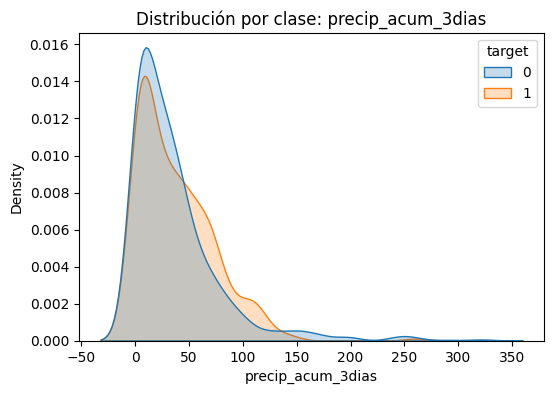

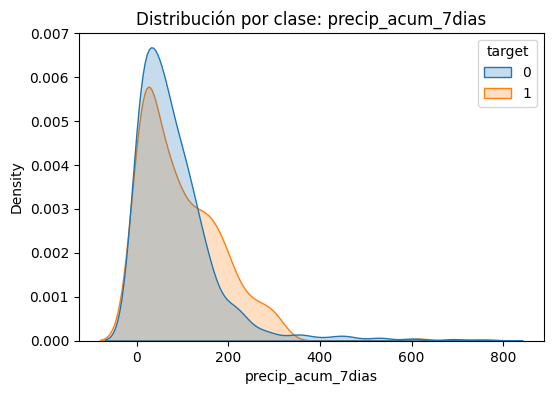

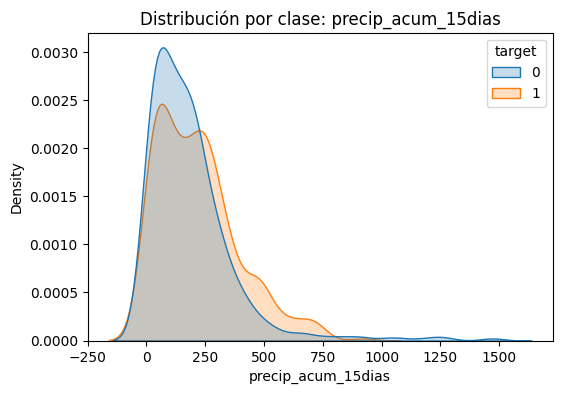

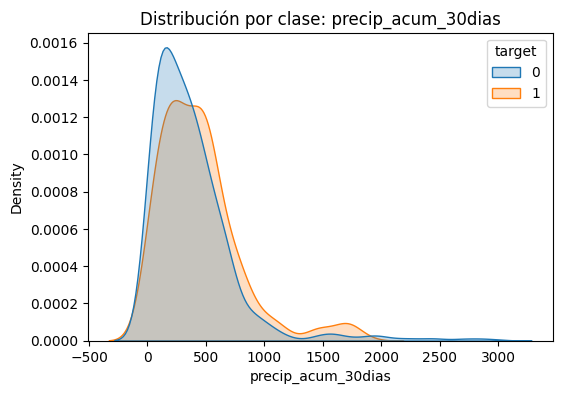

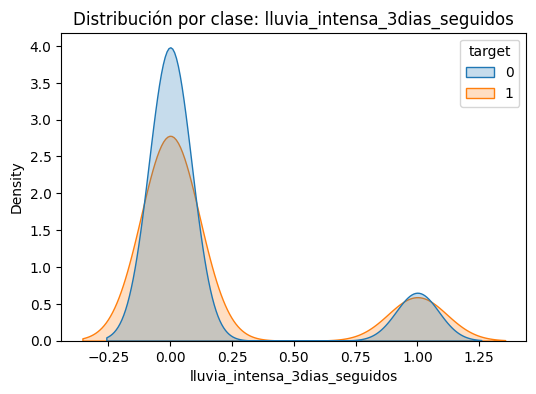

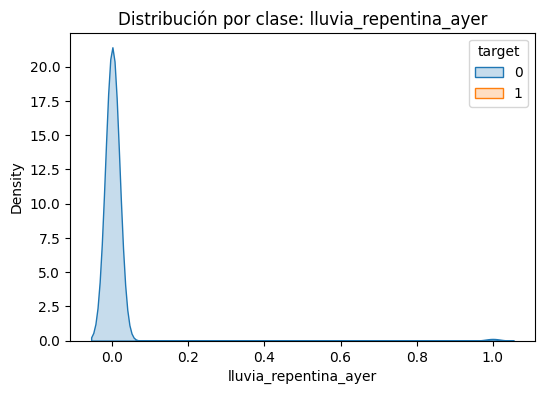

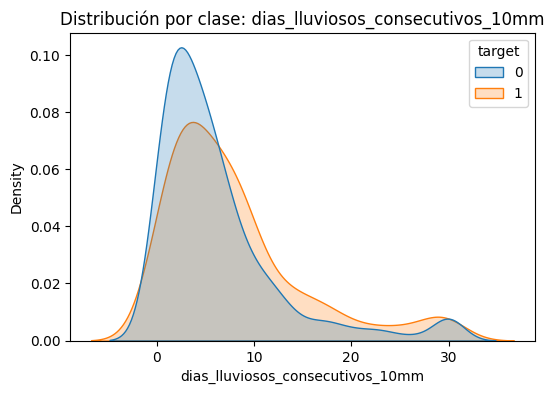

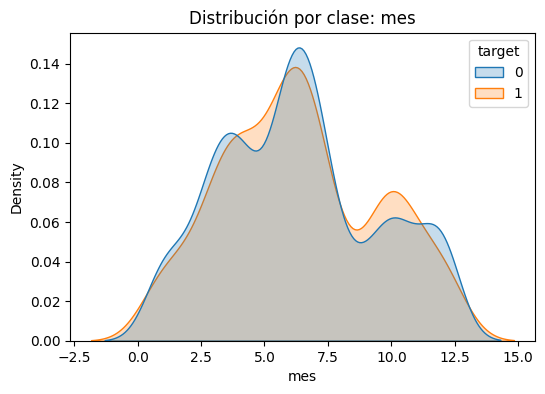

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in features_clima:  # features = lista de columnas numéricas
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue="target", common_norm=False, fill=True)
    plt.title(f'Distribución por clase: {col}')
    plt.show()
